In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# NOTE: sklearn is NOT used — all implementations are from scratch using NumPy
# as required by the project rules.

In [2]:
# Use a relative path so the notebook works on any machine
df = pd.read_csv('regression.csv')

In [3]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


In [5]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [6]:
# Define Our Target
y = df['FinalGrade']

In [7]:
# Drop identifiers (no predictive value) and redundant columns:
# - 'AttendanceRate' and 'Attendance (%)' measure the same concept on different scales (corr ≈ 0.01)
# - 'Study Hours' and 'StudyHoursPerWeek' are redundant; 'Study Hours' has impossible negative values
X = df.drop(
    ['FinalGrade', 'StudentID', 'Name', 'AttendanceRate', 'Study Hours'],
    axis=1, errors='ignore'
)

In [8]:
# Splitting data into train (80%) and test (20%) — implemented from scratch using NumPy
# IMPORTANT: split BEFORE any preprocessing to prevent data leakage

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)  # ensures every team member gets the same split

n = len(X)
indices = np.arange(n)         # array [0, 1, 2, ..., n-1]
np.random.shuffle(indices)     # shuffle in-place using fixed seed

split_point = int(n * 0.80)    # 80% train, 20% test
train_idx = indices[:split_point]
test_idx  = indices[split_point:]

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test  = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test  = y.iloc[test_idx].reset_index(drop=True)

print(f'Train size : {len(X_train)} rows ({len(X_train)/n*100:.0f}%)')
print(f'Test  size : {len(X_test)}  rows ({len(X_test)/n*100:.0f}%)')

# Sanity check — no overlap
assert len(set(train_idx) & set(test_idx)) == 0, 'Overlap detected!'
print('No overlap between train and test — split is clean.')

Train size : 800 rows (80%)
Test  size : 200  rows (20%)
No overlap between train and test — split is clean.


In [9]:
X_train.isnull().sum()

Gender                       32
StudyHoursPerWeek            38
PreviousGrade                23
ExtracurricularActivities    35
ParentalSupport              19
Attendance (%)               34
Online Classes Taken         22
dtype: int64

In [10]:
X_test.isnull().sum()

Gender                       16
StudyHoursPerWeek            12
PreviousGrade                10
ExtracurricularActivities     8
ParentalSupport               3
Attendance (%)                7
Online Classes Taken          3
dtype: int64

In [11]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [12]:
cat_cols = X_train.select_dtypes(include=['object','bool']).columns

In [13]:
# 2. Handle missing values
# Strategy:
#   - Numeric columns  → fill with MEDIAN (robust to outliers, unlike mean)
#   - Categorical cols → fill with MODE  (most frequent category)
# IMPORTANT: statistics are computed from X_train only, then applied to X_test
#            to prevent data leakage.

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns

train_medians = X_train[num_cols].median()      # compute from train only
train_modes   = X_train[cat_cols].mode().iloc[0]

for col in num_cols:
    X_train[col] = X_train[col].fillna(train_medians[col])
    X_test[col]  = X_test[col].fillna(train_medians[col])   # use train median!

for col in cat_cols:
    X_train[col] = X_train[col].fillna(train_modes[col])
    X_test[col]  = X_test[col].fillna(train_modes[col])     # use train mode!

C:\Users\PC 118\AppData\Local\Temp\ipykernel_35636\610446064.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].fillna(train_modes[col])
C:\Users\PC 118\AppData\Local\Temp\ipykernel_35636\610446064.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[col]  = X_test[col].fillna(train_modes[col])     # use train mode!


In [14]:
X_train.isnull().sum()

Gender                       0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
Attendance (%)               0
Online Classes Taken         0
dtype: int64

In [15]:
X_test.isnull().sum()

Gender                       0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
Attendance (%)               0
Online Classes Taken         0
dtype: int64

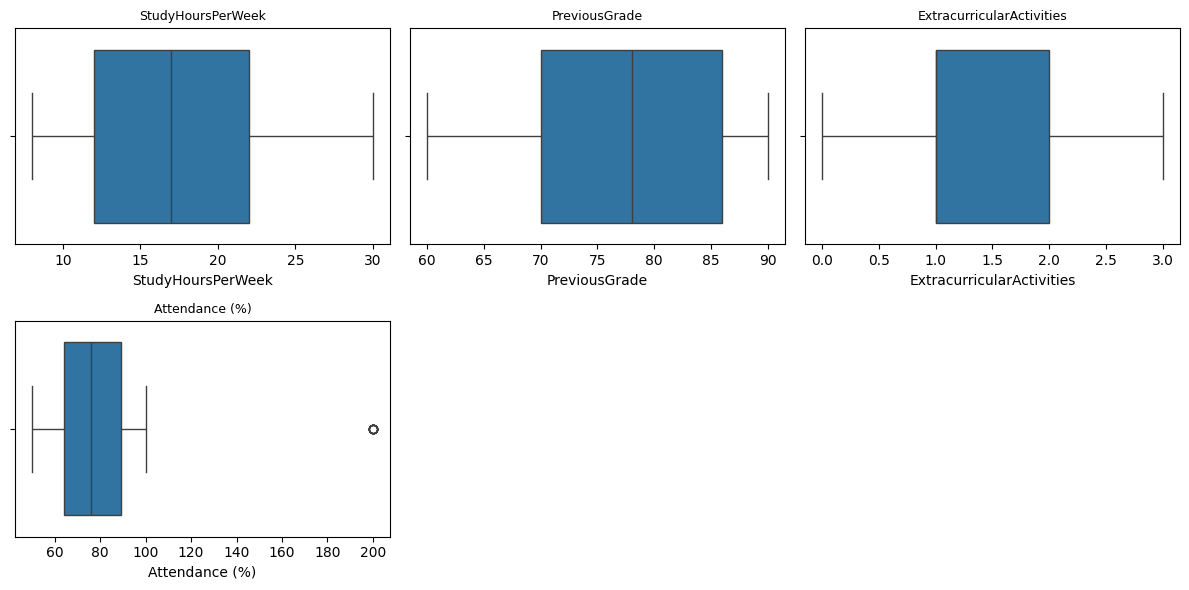

In [16]:
# Loop through numeric features and plot boxplots
# Select numeric features
# Select numeric features
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns

# Define grid size (2 rows × 3 columns)
n_cols = 3
n_rows = 2

plt.figure(figsize=(12, 6))

for i, feature in enumerate(numeric_features[:n_cols*n_rows], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=X_train[feature])
    plt.title(feature, fontsize=9)

plt.tight_layout()
plt.show()



# Observations from Boxplots:
# - Boxplots show the distribution of numeric features and highlight potential outliers.
# - Some features (e.g., AttendanceRate, StudyHoursPerWeek) show a few points outside the whiskers,
#   which may indicate outliers in the data.
# - Outliers can skew the model and affect performance, especially for algorithms sensitive to scale
#   (like linear regression, logistic regression, SVM).
# - However, tree-based models (Random Forest, XGBoost) are usually more robust to outliers.
# - Decision: Whether to handle outliers depends on the chosen model and business context.
#   Options include removing them, capping/extreme value treatment, or applying transformations.
# - In this dataset, outliers are not extreme or frequent, so handling them may not be strictly necessary,
#   but documenting their presence is important for transparency.

In [17]:
# Outlier handling — cap impossible values using domain knowledge
#
# WHY clip instead of IQR row removal:
#   - Removing rows breaks alignment between X_train and y_train
#     (X_train shrinks but y_train stays the same size → shape mismatch error)
#   - IQR removal is also not applied to X_test, creating inconsistency
#   - Clipping fixes the impossible value while keeping all rows intact
#
# Rule: Attendance (%) physically cannot exceed 100%
#       Values of 200 are clear data-entry errors → cap at 100
# This is a domain rule, not a statistical one, so applying to both sets is safe.

if 'Attendance (%)' in X_train.columns:
    X_train['Attendance (%)'] = X_train['Attendance (%)'].clip(upper=100)
    X_test['Attendance (%)']  = X_test['Attendance (%)'].clip(upper=100)
    print('Attendance (%) capped at 100 in both train and test.')

# For reference: the IQR function below is kept for documentation purposes only
def iqr_bounds(series):
    """Returns (lower, upper) IQR bounds — for inspection, not removal."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

Attendance (%) capped at 100 in both train and test.


In [18]:
# Encoding must happen BEFORE scaling so that encoded columns are also scaled.
# The actual scaling step is done in the cell after encoding.
#
# WHY scaling matters:
#   - Gradient Descent converges faster when all features share the same scale
#   - Without scaling, a feature like StudyHoursPerWeek (8-30) would dominate
#     Gender (0-1) in the loss surface
#
# Formula: X_scaled = (X - mean_train) / std_train
# IMPORTANT: mean and std are computed from X_train only, then applied to X_test

print('Encoding will happen next (cells below).')
print('Scaling will be applied after encoding to cover all columns.')

Encoding will happen next (cells below).
Scaling will be applied after encoding to cover all columns.


In [19]:
# Encode categorical columns using manual mapping (binary and ordinal)
# WHY manual map instead of get_dummies:
#   - get_dummies on train and test separately can produce different columns
#     if a category appears in one but not the other
#   - Manual mapping guarantees identical columns in both sets from the start

# Gender — binary: Male=1, Female=0
gender_map = {'Male': 1, 'Female': 0}
X_train['Gender'] = X_train['Gender'].map(gender_map)
X_test['Gender']  = X_test['Gender'].map(gender_map)

# ParentalSupport — ordinal: Low < Medium < High (natural order exists)
support_map = {'Low': 0, 'Medium': 1, 'High': 2}
X_train['ParentalSupport'] = X_train['ParentalSupport'].map(support_map)
X_test['ParentalSupport']  = X_test['ParentalSupport'].map(support_map)

# Online Classes Taken — boolean to integer: True=1, False=0
X_train['Online Classes Taken'] = X_train['Online Classes Taken'].astype(int)
X_test['Online Classes Taken']  = X_test['Online Classes Taken'].astype(int)

print('Encoding complete.')
print(X_train[['Gender', 'ParentalSupport', 'Online Classes Taken']].head(4))

Encoding complete.
   Gender  ParentalSupport  Online Classes Taken
0       0                0                     1
1       0                2                     0
2       0                0                     1
3       1                2                     1


In [20]:
# Z-score standardization — implemented from scratch using NumPy (no sklearn!)
#
# Compute mean and std from X_train only, then apply to both sets.
# Applying test stats to the scaler would be data leakage.

X_train_arr = X_train.values.astype(float)
X_test_arr  = X_test.values.astype(float)

train_mean = X_train_arr.mean(axis=0)   # one mean per feature
train_std  = X_train_arr.std(axis=0)    # one std  per feature
train_std[train_std == 0] = 1           # avoid division by zero

X_train_scaled = (X_train_arr - train_mean) / train_std
X_test_scaled  = (X_test_arr  - train_mean) / train_std  # use TRAIN stats!

feature_names = X_train.columns.tolist()

print(f'X_train_scaled shape : {X_train_scaled.shape}')
print(f'X_test_scaled  shape : {X_test_scaled.shape}')
print(f'Mean check (should be ~0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Std  check (should be ~1): {X_train_scaled.std(axis=0).round(3)}')

X_train_scaled shape : (800, 7)
X_test_scaled  shape : (200, 7)
Mean check (should be ~0): [-0. -0. -0.  0. -0. -0. -0.]
Std  check (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


In [21]:
# Verify that train and test have identical columns after manual encoding
# (No need for .align() since we used manual map — columns are guaranteed to match)

assert list(X_train.columns) == list(X_test.columns), \
    'Column mismatch between train and test!'

print('Column alignment check passed.')
print(f'X_train : {X_train_scaled.shape}')
print(f'X_test  : {X_test_scaled.shape}')
print(f'Features: {feature_names}')

Column alignment check passed.
X_train : (800, 7)
X_test  : (200, 7)
Features: ['Gender', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Attendance (%)', 'Online Classes Taken']


In [22]:
# Check that both datasets now have the same number of columns
print(X_train.shape)
print(X_test.shape)

(800, 7)
(200, 7)


In [23]:
# Add target column to training features for correlation analysis
df_corr = X_train.copy()
df_corr['FinalGrade'] = y_train

# Compute correlation matrix for numeric columns only
corr_matrix = df_corr.corr(numeric_only=True)

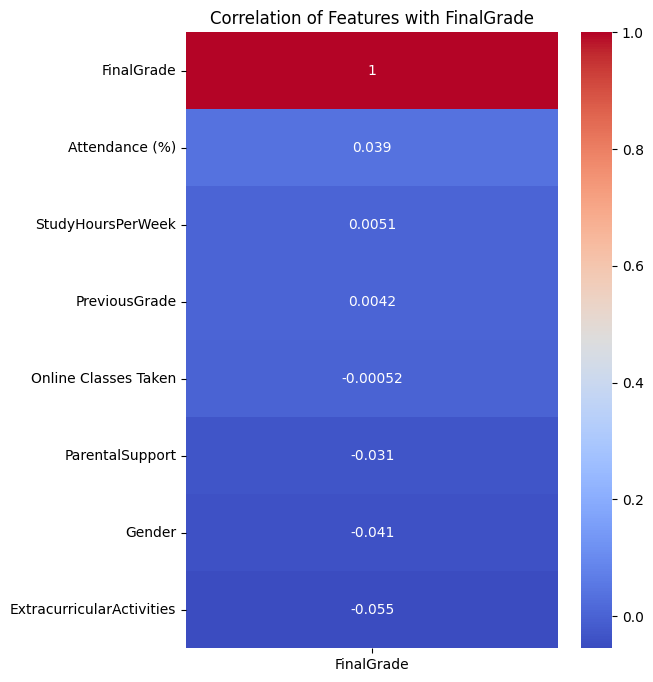

In [24]:
# First heatmap: makes it clear which features are most strongly correlated with the target (FinalGrade).

plt.figure(figsize=(6,8))
sns.heatmap(
    corr_matrix[['FinalGrade']].sort_values(by='FinalGrade', ascending=False),
    annot=True,          # show correlation values
    cmap="coolwarm"      # color scheme
)
plt.title("Correlation of Features with FinalGrade")
plt.show()

In [25]:
# ============================================================
# Save all processed data as CSV files
# ============================================================
# Files saved:
#   train_features_scaled.csv  — X_train after scaling  (use for modeling)
#   train_target.csv           — y_train (FinalGrade values for train)
#   test_features_scaled.csv   — X_test  after scaling  (LOCKED — final eval only)
#   test_target.csv            — y_test  (FinalGrade values for test)
#   train_features_raw.csv     — X_train before scaling (readable values)
#   test_features_raw.csv      — X_test  before scaling (readable values)
# ============================================================

import pandas as pd
import numpy as np

# --- Scaled versions (NumPy arrays → DataFrame with column names) ---
df_X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
df_X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names)

# --- Unscaled versions (already DataFrames) ---
df_X_train_raw = X_train.copy()
df_X_test_raw  = X_test.copy()

# --- Target vectors ---
df_y_train = pd.DataFrame({'FinalGrade': y_train})
df_y_test  = pd.DataFrame({'FinalGrade': y_test})

# --- Save all files ---
df_X_train_scaled.to_csv('train_features_scaled.csv', index=False)
df_X_test_scaled.to_csv('test_features_scaled.csv',   index=False)
df_X_train_raw.to_csv('train_features_raw.csv',       index=False)
df_X_test_raw.to_csv('test_features_raw.csv',         index=False)
df_y_train.to_csv('train_target.csv',                 index=False)
df_y_test.to_csv('test_target.csv',                   index=False)

# --- Summary ---
files = [
    ('train_features_scaled.csv', df_X_train_scaled.shape, 'X_train — scaled, use for modeling & CV'),
    ('train_target.csv',          df_y_train.shape,        'y_train — FinalGrade for train rows'),
    ('test_features_scaled.csv',  df_X_test_scaled.shape,  'X_test  — scaled, LOCKED until final eval'),
    ('test_target.csv',           df_y_test.shape,         'y_test  — FinalGrade for test rows'),
    ('train_features_raw.csv',    df_X_train_raw.shape,    'X_train — unscaled, human-readable'),
    ('test_features_raw.csv',     df_X_test_raw.shape,     'X_test  — unscaled, human-readable'),
]

print('=' * 65)
print(f'{"File":<30} {"Shape":<12} Description')
print('=' * 65)
for name, shape, desc in files:
    print(f'{name:<30} {str(shape):<12} {desc}')
print('=' * 65)
print('All files saved successfully in the current working directory.')


File                           Shape        Description
train_features_scaled.csv      (800, 7)     X_train — scaled, use for modeling & CV
train_target.csv               (800, 1)     y_train — FinalGrade for train rows
test_features_scaled.csv       (200, 7)     X_test  — scaled, LOCKED until final eval
test_target.csv                (200, 1)     y_test  — FinalGrade for test rows
train_features_raw.csv         (800, 7)     X_train — unscaled, human-readable
test_features_raw.csv          (200, 7)     X_test  — unscaled, human-readable
All files saved successfully in the current working directory.


In [26]:
import os
print(os.getcwd())  

e:\
